# ⚾ 어떤 회피가 유리한가 — 회피 × (맞은 구종 의존도, 대체구종 사전 성과) 상호작용 검증

* **작성자:** DY
* **작성일:** 2026-10-05
* **질문:** "회피는 합리적인가?"(전체 평균 효과 — 노트북 3·4·6·7에서 모두 유의하지 않음)에서 **"회피가 유리해지는 조건은 무엇인가?"**로 질문을 좁힙니다. 지금까지의 회피 변수는 서로 다른 두 행동을 하나로 묶고 있었습니다.
  * 좋은 대체구종이 있어서 맞은 구종을 피하는 경우
  * 주력구를 포기하고 상대적으로 약한 구종을 쓰는 경우

  이 둘은 결과가 다를 수 있으므로, 결과를 보기 전에 아래 두 조절변수를 **미리 정하고** 회피(`avoided`)와의 상호작용을 검정합니다.

| 조절변수 | 정의 (모두 해당 재대결 **이전 경기**까지의 기록만 사용) | 검증할 질문 |
|---|---|---|
| `hit_reliance` — 맞은 구종의 평소 의존도 | 투수의 사전 투구 중 맞은 구종 비율(주 분석은 연속값, 보조로 "투수의 최다 사용 구종인가" 이진값) | 주력구를 피할 때와 비주력구를 피할 때 효과가 다른가? |
| `alt_quality` — 대체구종의 사전 성과 | 맞은 구종을 제외한 사전 사용률 5% 이상 구종들의 사전 RVAE(낮을수록 투수에게 유리)를 **경험적 베이즈로 수축**(n/(n+k))한 값의 최선값(부호를 뒤집어 클수록 좋은 대체구종) | 좋은 대체구종이 있는 투수에게 회피가 더 유리한가? |

* **표본이 적은 구종의 보정:** 구종별 사전 RVAE는 타석을 끝낸 투구만 쓰므로 표본이 작습니다. `shrunk = Σrvae / (n + k)`로 0(리그 평균) 쪽으로 당기고, `k = σ²/τ²`는 투수×구종 평균의 모멘트 추정으로 구합니다(민감도로 k의 0.5배·2배도 확인).
* **사전 지정(분석 후 바꾸지 않음):** 결과 변수 2개 × 조절변수 2개 = 상호작용 검정 4개를 Holm 보정 대상으로 고정합니다. 결과 변수는 ① `woba_value`(재대결 결정구의 실제 wOBA, 낮을수록 투수에게 유리) ② `allowed_xbh_again`(재대결에서 또 장타). 구종 선택 자체가 회피의 경로이므로 주 모형은 `pitch_family`를 통제하지 **않습니다**(매개변수 통제 방지). 노트북 7 방식(RVAE + `pitch_family` 통제)은 로버스트니스로 둡니다.
* **한계(미리):** 회피는 무작위 배정이 아니라 투수의 선택이라, 상호작용도 인과가 아닌 관측적 연관입니다.

In [1]:
# 1. 경로 설정 (src 폴더 접근용)
import sys, os
sys.path.append(os.path.abspath('..'))

# 2. Autoreload 설정
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.analysis.avoidance_conditions import add_prior_pitch_features, estimate_shrinkage_k, holm_adjust
from src.analysis.avoidance_stats import compute_season_usage_rate
from src.analysis.glmer_runner import (
    check_convergence,
    extract_fixed_effects_table,
    extract_lmer_fixed_effects,
    extract_variance_components,
    fit_glmer,
    fit_lmer,
)
from src.analysis.mixed_effects_model import compute_icc, compute_icc_gaussian
from src.analysis.run_same_batter_rematch_analysis import build_xbh_rematch
from src.preprocessing.build_next_ab_dataset import EXTRA_BASE_HIT_EVENTS
from src.preprocessing.pitch_family import map_pitch_family
from src.preprocessing.research_sample import KEY_COLUMNS, list_research_csvs

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

TRAIN_SEASONS = (2021, 2022, 2023, 2024, 2025)
VALID_SEASON = 2026
RANDOM_STATE = 20261003
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path('..') / 'data' / 'processed' / 'figures'

Error importing in API mode: ImportError("dlopen(/Users/dongyunkwak/GitHub/9th-first-project-baseball-2/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib\n  Referenced from: <9F0E20C3-D782-31B5-943E-66F62BCE77E8> /Users/dongyunkwak/GitHub/9th-first-project-baseball-2/.venv/lib/python3.14/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


## 1. 데이터와 재대결 이벤트 (노트북 7과 동일 파이프라인)

팀 CSV 6개 → 상황 피처 → 장타 재대결 이벤트 27,391건 → 결정구 GBM(RVAE 기준). 새 로직은 3절부터입니다.

In [2]:
LOAD_COLUMNS = [
    'game_pk', 'game_date', 'at_bat_number', 'pitch_number', 'pitcher', 'player_name', 'batter',
    'stand', 'p_throws', 'pitch_type', 'events', 'balls', 'strikes', 'outs_when_up',
    'inning', 'inning_topbot', 'on_1b', 'on_2b', 'on_3b', 'home_score', 'away_score',
    'woba_value', 'woba_denom',
]


def load_team_csv() -> pd.DataFrame:
    frames = [
        pd.read_csv(path, usecols=LOAD_COLUMNS, encoding='utf-8-sig', low_memory=False)
        for path in list_research_csvs()
    ]
    pitches = pd.concat(frames, ignore_index=True)
    pitches['season'] = pd.to_datetime(pitches['game_date']).dt.year
    return pitches


pitches = load_team_csv()
assert len(pitches) == 3_592_302 and pitches['pitcher'].nunique() == 1_067
assert not pitches.duplicated(KEY_COLUMNS).any()
print(f'{len(pitches):,}행, 투수 {pitches["pitcher"].nunique():,}명')

3,592,302행, 투수 1,067명


In [3]:
SITUATION_COLUMNS = ['runners_n', 'risp', 'score_diff', 'platoon_match']


def add_situation_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    on1, on2, on3 = out['on_1b'].notna(), out['on_2b'].notna(), out['on_3b'].notna()
    out['runners_n'] = on1.astype(int) + on2.astype(int) + on3.astype(int)
    out['risp'] = (on2 | on3).astype(int)
    out['score_diff'] = np.where(
        out['inning_topbot'] == 'Top', out['home_score'] - out['away_score'], out['away_score'] - out['home_score']
    )
    out['platoon_match'] = np.where(
        out['stand'].isna() | out['p_throws'].isna(), np.nan, (out['stand'] == out['p_throws']).astype(float)
    )
    return out

In [4]:
pitches = add_situation_columns(pitches)
season_usage = compute_season_usage_rate(pitches)
xbh = build_xbh_rematch(pitches, season_usage)
xbh = xbh[xbh['has_next_ab']].copy()
assert len(xbh) == 27_391, len(xbh)
print(f'재대결 이벤트 {len(xbh):,}건')

2026-10-05 20:04:05,715 [INFO] 장타 70319건 중 같은 타자·같은 투수 재대결 27391건 (39.0%)
        xbh_total  same_batter_rematch  rematch_share
season                                               
2021        12709                 4688         0.3689
2022        12186                 4623         0.3794
2023        13137                 5280         0.4019
2024        12427                 4977         0.4005
2025        12394                 4916         0.3966
2026         7466                 2907         0.3894


재대결 이벤트 27,391건


In [5]:
MODEL_FEATURES = [
    'pitch_type', 'stand', 'p_throws', 'balls', 'strikes', 'outs_when_up', 'runners_n', 'risp', 'score_diff',
    'season_usage_rate',
]
CATEGORICAL_FEATURES = ['pitch_type', 'stand', 'p_throws']


def build_decisive_pitch_table(pitches_sit: pd.DataFrame, season_usage_: pd.DataFrame) -> pd.DataFrame:
    decisive = pitches_sit[pitches_sit['woba_value'].notna() & pitches_sit['pitch_type'].notna()].copy()
    decisive = decisive.merge(
        season_usage_[['pitcher', 'season', 'pitch_type', 'season_usage_rate']],
        on=['pitcher', 'season', 'pitch_type'], how='left',
    )
    for col in CATEGORICAL_FEATURES:
        decisive[col] = decisive[col].astype('category')
    return decisive

In [6]:
decisive_table = build_decisive_pitch_table(pitches, season_usage)
assert decisive_table['season_usage_rate'].notna().mean() > 0.99, '구사율 매칭 실패 비율이 높음'
print(f'결정구 {len(decisive_table):,}건, season_usage_rate 결측 {decisive_table["season_usage_rate"].isna().sum()}건')

결정구 917,717건, season_usage_rate 결측 0건


In [7]:
def fit_run_value_model(table: pd.DataFrame, seasons) -> HistGradientBoostingRegressor:
    train = table[table['season'].isin(seasons)]
    model = HistGradientBoostingRegressor(
        categorical_features='from_dtype', random_state=RANDOM_STATE, max_iter=200, early_stopping=True,
    )
    model.fit(train[MODEL_FEATURES], train['woba_value'])
    return model

In [8]:
train_set = decisive_table[decisive_table['season'].isin(TRAIN_SEASONS)]
valid_set = decisive_table[decisive_table['season'] == VALID_SEASON]
model_cv = fit_run_value_model(decisive_table, TRAIN_SEASONS)
pred_valid = model_cv.predict(valid_set[MODEL_FEATURES])
baseline_mae = mean_absolute_error(valid_set['woba_value'], np.full(len(valid_set), train_set['woba_value'].mean()))
model_mae = mean_absolute_error(valid_set['woba_value'], pred_valid)
model_mse = mean_squared_error(valid_set['woba_value'], pred_valid)
model_r2 = r2_score(valid_set['woba_value'], pred_valid)
print(f'베이스라인(평균 예측) MAE: {baseline_mae:.4f}')
print(f'GBM MAE: {model_mae:.4f} (베이스라인 대비 {(baseline_mae - model_mae) / baseline_mae:.1%}, 참고용)')
print(f'GBM MSE: {model_mse:.4f}, R²: {model_r2:.4f} (평균만 예측하면 R²=0)')
assert model_r2 > 0, 'GBM이 평균만 예측하는 것보다 분산을 못 줄임 -- 피처/학습을 재검토해야 함'

final_model = fit_run_value_model(decisive_table, decisive_table['season'].unique())
print('전체 데이터로 재학습한 최종 모델 준비 완료')

베이스라인(평균 예측) MAE: 0.4322
GBM MAE: 0.3989 (베이스라인 대비 7.7%, 참고용)
GBM MSE: 0.2445, R²: 0.0568 (평균만 예측하면 R²=0)


전체 데이터로 재학습한 최종 모델 준비 완료


In [9]:
def compute_rvae(df: pd.DataFrame, model) -> pd.Series:
    expected = model.predict(df[MODEL_FEATURES])
    return df['woba_value'] - expected

In [10]:
def find_rematch_outcome_pitch(xbh_: pd.DataFrame, pitches_sit: pd.DataFrame) -> pd.DataFrame:
    decisive = pitches_sit[pitches_sit['woba_value'].notna()][
        ['game_pk', 'pitcher', 'season', 'at_bat_number', *MODEL_FEATURES, 'platoon_match', 'events', 'woba_value']
    ]
    keys = xbh_[['game_pk', 'pitcher', 'next_at_bat_number', 'reused_same_type']].rename(
        columns={'next_at_bat_number': 'at_bat_number'}
    )
    out = keys.merge(decisive, on=['game_pk', 'pitcher', 'at_bat_number'], how='left', validate='many_to_one')
    return out

In [11]:
REQUIRED_OUTCOME_COLUMNS = sorted(set(['events', 'woba_value', 'platoon_match', *MODEL_FEATURES]))


def build_avoidance_outcome_dataset(found: pd.DataFrame) -> pd.DataFrame:
    out = found.copy()
    out['pitch_family'] = out['pitch_type'].map(map_pitch_family)
    out = out.dropna(subset=[*REQUIRED_OUTCOME_COLUMNS, 'pitch_family', 'reused_same_type'])
    out['avoided'] = (1 - out['reused_same_type']).astype(int)
    out['allowed_xbh_again'] = out['events'].isin(EXTRA_BASE_HIT_EVENTS).astype(int)
    out['pitcher'] = out['pitcher'].astype(str)
    return out

## 2. 모델링 데이터 + 사전 투구 조절변수

노트북 7의 `model_data`에 재대결 이벤트의 `game_date`·맞은 구종(`hit_pitch_type`)을 붙입니다. RVAE는 GBM 기대값 대비 잔차라서 구종별 평균이 0 근처이므로, 구종 사전 성과를 0 쪽으로 수축하는 것이 자연스럽습니다.

In [12]:
found = find_rematch_outcome_pitch(xbh, decisive_table)
missing = found['woba_value'].isna().sum()
model_data = build_avoidance_outcome_dataset(found.dropna(subset=['woba_value']))
model_data['rvae'] = compute_rvae(model_data, final_model)
print(f'재대결 {len(found):,}건 -> 결정구 없음 {missing}건 제외 -> 모델링 {len(model_data):,}건 (노트북 7과 동일해야 함: 27,245)')
assert len(model_data) == 27_245, len(model_data)

# 이벤트 메타(game_date, hit_pitch_type) 부착. 키: game_pk, pitcher, next_at_bat_number
meta = xbh[['game_pk', 'pitcher', 'next_at_bat_number', 'game_date', 'hit_pitch_type']].copy()
meta['pitcher'] = meta['pitcher'].astype(str)
found_keys = found[['game_pk', 'pitcher', 'at_bat_number']].copy()
found_keys['pitcher'] = found_keys['pitcher'].astype(str)
model_data = model_data.merge(
    meta.rename(columns={'next_at_bat_number': 'at_bat_number'}),
    on=['game_pk', 'pitcher', 'at_bat_number'], how='left', validate='one_to_one',
)
model_data['game_date'] = pd.to_datetime(model_data['game_date'])
assert model_data['game_date'].notna().all() and model_data['hit_pitch_type'].notna().all()
print('이벤트 메타 부착 완료:', len(model_data))

재대결 27,391건 -> 결정구 없음 135건 제외 -> 모델링 27,245건 (노트북 7과 동일해야 함: 27,245)
이벤트 메타 부착 완료: 27245


In [13]:
# 사전 투구 테이블: 모든 투구 + (결정구에만) RVAE
pt = pitches[['pitcher', 'game_date', 'pitch_type', 'game_pk', 'at_bat_number', 'pitch_number']].copy()
pt['pitcher'] = pt['pitcher'].astype(str)
pt['game_date'] = pd.to_datetime(pt['game_date'])
dec = decisive_table[['game_pk', 'pitcher', 'at_bat_number', 'pitch_number', 'woba_value', *MODEL_FEATURES]].copy() \
    if 'pitch_number' in decisive_table.columns else None
assert dec is not None, 'decisive_table에 pitch_number가 없음'
dec['rvae'] = compute_rvae(dec, final_model)
dec['pitcher'] = dec['pitcher'].astype(str)
pt = pt.merge(dec[['game_pk', 'pitcher', 'at_bat_number', 'pitch_number', 'rvae']],
              on=['game_pk', 'pitcher', 'at_bat_number', 'pitch_number'], how='left', validate='one_to_one')
print(f'사전 투구 테이블 {len(pt):,}행, 결정구 RVAE {pt["rvae"].notna().sum():,}개')

K = estimate_shrinkage_k(pt.dropna(subset=['rvae']).dropna(subset=['pitch_type']))
print(f'경험적 베이즈 수축 상수 k = {K:.1f} (구종 사전 결정구 n=k일 때 관측값 가중치 50%)')

사전 투구 테이블 3,592,302행, 결정구 RVAE 917,717개
경험적 베이즈 수축 상수 k = 459.2 (구종 사전 결정구 n=k일 때 관측값 가중치 50%)


In [14]:
MIN_PRIOR_PITCHES = 200
feat = add_prior_pitch_features(model_data, pt, shrinkage_k=K, min_alt_usage=0.05, min_prior_pitches=MIN_PRIOR_PITCHES)
n0 = len(feat)
excl_thin = (feat['n_prior_pitches'] < MIN_PRIOR_PITCHES).sum()
excl_noalt = ((feat['n_prior_pitches'] >= MIN_PRIOR_PITCHES) & (feat['n_alternatives'] == 0)).sum()
print(f'재대결 {n0:,}건 중 사전 투구 {MIN_PRIOR_PITCHES}개 미만(첫 시즌 초반 등) {excl_thin:,}건, 대체구종 없음 {excl_noalt:,}건 제외 대상')
mod = feat.dropna(subset=['hit_prior_usage', 'alt_rvae_best']).copy()
print(f'조절변수 분석 표본: {len(mod):,}건, 투수 {mod["pitcher"].nunique()}명, 회피 {mod["avoided"].mean():.1%}')
mod['hit_reliance_z'] = (mod['hit_prior_usage'] - mod['hit_prior_usage'].mean()) / mod['hit_prior_usage'].std()
mod['alt_quality'] = -mod['alt_rvae_best']
mod['alt_quality_z'] = (mod['alt_quality'] - mod['alt_quality'].mean()) / mod['alt_quality'].std()
mod['alt_quality_w_z'] = ((-mod['alt_rvae_wmean']) - (-mod['alt_rvae_wmean']).mean()) / (-mod['alt_rvae_wmean']).std()
mod['hit_is_primary'] = mod['hit_is_primary'].astype(int)
display(mod[['hit_prior_usage', 'hit_is_primary', 'alt_rvae_best', 'alt_quality_z', 'n_alternatives', 'avoided']].describe().round(3))
print('두 조절변수의 상관(다중공선성 확인):', round(mod['hit_reliance_z'].corr(mod['alt_quality_z']), 3))
print('회피율 — 주력구 맞음:', round(mod.loc[mod.hit_is_primary == 1, 'avoided'].mean(), 3), '/ 비주력구 맞음:', round(mod.loc[mod.hit_is_primary == 0, 'avoided'].mean(), 3))

재대결 27,245건 중 사전 투구 200개 미만(첫 시즌 초반 등) 1,315건, 대체구종 없음 0건 제외 대상
조절변수 분석 표본: 25,904건, 투수 667명, 회피 54.5%


,hit_prior_usage,hit_is_primary,alt_rvae_best,alt_quality_z,n_alternatives,avoided
count,25904.000,25904.000,25904.000,25904.000,25904.000,25904.000
mean,0.296,0.423,-0.009,0.000,3.423,0.545
std,0.154,0.494,0.009,1.000,0.952,0.498
min,0.000,0.000,-0.041,-3.899,1.000,0.000
25%,0.177,0.000,-0.014,-0.670,3.000,0.000
50%,0.281,0.000,-0.008,-0.093,3.000,1.000
75%,0.417,1.000,-0.003,0.591,4.000,1.000
max,0.764,1.000,0.026,3.607,7.000,1.000


두 조절변수의 상관(다중공선성 확인): -0.137
회피율 — 주력구 맞음: 0.369 / 비주력구 맞음: 0.674


## 3. 상호작용 모형

고정효과: 회피, 조절변수, 회피×조절변수, 상황(볼카운트·아웃·점수차·투타 상성), 시즌. 랜덤 절편: 투수. 두 조절변수는 z점수라서 `avoided` 계수는 "조절변수가 평균일 때의 회피 효과", 상호작용 계수는 "조절변수가 1 SD 클 때 회피 효과가 얼마나 바뀌는가"입니다. 결과가 `woba_value`(낮을수록 투수에게 유리)이므로 **음수 = 회피가 더 유리**.

In [15]:
CTRL = 'balls + strikes + outs_when_up + score_diff + platoon_match + factor(season)'
results = {}

def run_model(name, outcome, rhs, data=mod, kind=None):
    kind = kind or ('glmer' if outcome == 'allowed_xbh_again' else 'lmer')
    f = f'{outcome} ~ {rhs} + {CTRL} + (1 | pitcher)'
    if kind == 'lmer':
        fit_lmer(data, f); tab = extract_lmer_fixed_effects()
    else:
        fit_glmer(data, f); tab = extract_fixed_effects_table()
    conv = check_convergence()
    results[name] = {'table': tab.set_index('term'), 'conv': conv, 'n': len(data), 'kind': kind}
    return results[name]

def show(name, terms):
    r = results[name]
    cols = [c for c in ['estimate', 'std_error', 'ci_low', 'ci_high', 'p_value', 'odds_ratio'] if c in r['table'].columns]
    t = r['table'].loc[[x for x in terms if x in r['table'].index], cols]
    print(f'[{name}] n={r["n"]:,} | {r["conv"]}')
    display(t.round(4))

for outcome in ['woba_value', 'allowed_xbh_again']:
    run_model(f'{outcome}|M1 의존도', outcome, 'avoided * hit_reliance_z')
    run_model(f'{outcome}|M2 대체구종', outcome, 'avoided * alt_quality_z')
    run_model(f'{outcome}|M3 동시', outcome, 'avoided * hit_reliance_z + avoided * alt_quality_z')
    for m in ['M1 의존도', 'M2 대체구종', 'M3 동시']:
        show(f'{outcome}|{m}', ['avoided', 'hit_reliance_z', 'alt_quality_z', 'avoided:hit_reliance_z', 'avoided:alt_quality_z'])

2026-10-05 20:04:39,435 [WARNING] R callback write-console: Loading required package: Matrix
  


[woba_value|M1 의존도] n=25,904 | OK: no convergence warnings; isSingular=False


,estimate,std_error,ci_low,ci_high,p_value
term,,,,,
avoided,-0.0106,0.0074,-0.0251,0.0040,0.1538
hit_reliance_z,-0.0014,0.0051,-0.0114,0.0086,0.7833
avoided:hit_reliance_z,-0.0100,0.0070,-0.0238,0.0038,0.1549


[woba_value|M2 대체구종] n=25,904 | OK: no convergence warnings; isSingular=False


,estimate,std_error,ci_low,ci_high,p_value
term,,,,,
avoided,-0.0055,0.0069,-0.0192,0.0081,0.4239
alt_quality_z,-0.0083,0.0050,-0.0181,0.0016,0.0993
avoided:alt_quality_z,0.0084,0.0066,-0.0046,0.0213,0.2042


...

,estimate,std_error,p_value,odds_ratio
term,,,,
avoided,-0.0437,0.0505,0.3870,0.9572
hit_reliance_z,-0.0172,0.0352,0.6251,0.9829
avoided:hit_reliance_z,-0.0648,0.0473,0.1704,0.9372


[allowed_xbh_again|M2 대체구종] n=25,904 | OK: no convergence warnings; isSingular=False


,estimate,std_error,p_value,odds_ratio
term,,,,
avoided,-0.0051,0.0472,0.9143,0.9949
alt_quality_z,-0.0472,0.0351,0.1784,0.9539
avoided:alt_quality_z,0.0777,0.0450,0.0841,1.0808


[allowed_xbh_again|M3 동시] n=25,904 | OK: no convergence warnings; isSingular=False


,estimate,std_error,p_value,odds_ratio
term,,,,
avoided,-0.0409,0.0506,0.4191,0.9600
hit_reliance_z,-0.0218,0.0354,0.5374,0.9784
alt_quality_z,-0.0485,0.0352,0.1684,0.9527
avoided:hit_reliance_z,-0.0566,0.0477,0.2351,0.9450
avoided:alt_quality_z,0.0687,0.0453,0.1294,1.0712


In [16]:
# 사전 지정한 4개 검정(동시 모형 M3의 상호작용)에 Holm 보정
rows = []
for outcome in ['woba_value', 'allowed_xbh_again']:
    t = results[f'{outcome}|M3 동시']['table']
    for term in ['avoided:hit_reliance_z', 'avoided:alt_quality_z']:
        rows.append({'outcome': outcome, 'term': term, 'estimate': t.loc[term, 'estimate'],
                     'std_error': t.loc[term, 'std_error'], 'p_value': t.loc[term, 'p_value']})
primary = pd.DataFrame(rows)
primary['p_holm'] = holm_adjust(primary['p_value'].tolist())
display(primary.round(4))

,outcome,term,estimate,std_error,p_value,p_holm
0,woba_value,avoided:hit_reliance_z,-0.0093,0.0071,0.1881,0.5643
1,woba_value,avoided:alt_quality_z,0.0070,0.0067,0.2917,0.5643
2,allowed_xbh_again,avoided:hit_reliance_z,-0.0566,0.0477,0.2351,0.5643
3,allowed_xbh_again,avoided:alt_quality_z,0.0687,0.0453,0.1294,0.5176


## 4. 로버스트니스

결과가 모형·정의 선택에 휘둘리는지 봅니다 — ① 노트북 7 방식(RVAE, `pitch_family` 통제) ② 의존도를 "주력구 여부" 이진값으로 ③ 대체구종 성과를 사용률 가중 평균으로 ④ 수축 상수 k를 0.5배·2배로.

In [17]:
rob = []
def add_rob(label, name, term, outcome):
    t = results[name]['table']
    rob.append({'check': label, 'outcome': outcome, 'term': term, 'estimate': t.loc[term, 'estimate'],
                'ci_low': t.loc[term, 'ci_low'] if 'ci_low' in t else np.nan, 'p_value': t.loc[term, 'p_value']})

# ① RVAE + pitch_family 통제 (노트북 7 방식)
run_model('rob1', 'rvae', 'avoided * hit_reliance_z + avoided * alt_quality_z + pitch_family')
for term in ['avoided:hit_reliance_z', 'avoided:alt_quality_z']:
    add_rob('① RVAE+pitch_family', 'rob1', term, 'rvae')
# ② 주력구 이진
for outcome in ['woba_value', 'allowed_xbh_again']:
    run_model(f'rob2|{outcome}', outcome, 'avoided * hit_is_primary + avoided * alt_quality_z')
    add_rob('② 주력구 이진', f'rob2|{outcome}', 'avoided:hit_is_primary', outcome)
    # ③ 가중 평균 대체 성과
    run_model(f'rob3|{outcome}', outcome, 'avoided * hit_reliance_z + avoided * alt_quality_w_z')
    add_rob('③ 대체 성과=가중평균', f'rob3|{outcome}', 'avoided:alt_quality_w_z', outcome)
# ④ k 민감도
for mult in (0.5, 2.0):
    f2 = add_prior_pitch_features(model_data, pt, shrinkage_k=K * mult, min_alt_usage=0.05, min_prior_pitches=MIN_PRIOR_PITCHES)
    d2 = f2.dropna(subset=['hit_prior_usage', 'alt_rvae_best']).copy()
    d2['hit_reliance_z'] = (d2['hit_prior_usage'] - d2['hit_prior_usage'].mean()) / d2['hit_prior_usage'].std()
    d2['alt_quality_z'] = (-d2['alt_rvae_best'] - (-d2['alt_rvae_best']).mean()) / (-d2['alt_rvae_best']).std()
    for outcome in ['woba_value', 'allowed_xbh_again']:
        run_model(f'rob4|{mult}|{outcome}', outcome, 'avoided * hit_reliance_z + avoided * alt_quality_z', data=d2)
        add_rob(f'④ k×{mult}', f'rob4|{mult}|{outcome}', 'avoided:alt_quality_z', outcome)
rob = pd.DataFrame(rob)
display(rob.round(4))
print('수렴 이상 모형:', [k for k, v in results.items() if not v['conv'].startswith('OK')] or '없음')

,check,outcome,term,estimate,ci_low,p_value
0,① RVAE+pitch_family,rvae,avoided:hit_reliance_z,-0.0091,-0.0231,0.1984
1,① RVAE+pitch_family,rvae,avoided:alt_quality_z,0.0076,-0.0053,0.2494
2,② 주력구 이진,woba_value,avoided:hit_is_primary,-0.0229,-0.0503,0.1008
3,③ 대체 성과=가중평균,woba_value,avoided:alt_quality_w_z,0.0072,-0.0058,0.2768
4,② 주력구 이진,allowed_xbh_again,avoided:hit_is_primary,-0.0862,NaN,0.3592
5,③ 대체 성과=가중평균,allowed_xbh_again,avoided:alt_quality_w_z,0.0649,NaN,0.1487
6,④ k×0.5,woba_value,avoided:alt_quality_z,0.0058,-0.0072,0.3798
7,④ k×0.5,allowed_xbh_again,avoided:alt_quality_z,0.0600,NaN,0.1815
8,④ k×2.0,woba_value,avoided:alt_quality_z,0.0076,-0.0055,0.2529
9,④ k×2.0,allowed_xbh_again,avoided:alt_quality_z,0.0752,NaN,0.1006


수렴 이상 모형: 없음


## 5. 발표용 시각화 — 조건별 회피 효과

연속 상호작용 모형과 별개로, 조건 구간별로 회피 효과(`avoided` 계수, `woba_value`)를 따로 추정해 보여줍니다(각 구간에서 `avoided + 상황통제 + (1|투수)`). 구간 컷은 데이터 분포가 아니라 미리 정한 규칙(주력구 여부, 대체구종 성과 3분위)입니다.

2026-10-05 20:05:08,972 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


2026-10-05 20:05:10,952 [WARNING] R callback write-console: boundary (singular) fit: see help('isSingular')
  


,col,group,outcome,n,avoid_rate,estimate,ci_low,ci_high,p_value
0,reliance_group,비주력구 맞음,woba_value,14934,0.6744,0.0018,-0.0171,0.0207,0.8510
1,reliance_group,비주력구 맞음,allowed_xbh_again,14934,0.6744,-0.0046,-0.1344,0.1252,0.9445
2,reliance_group,주력구 맞음,woba_value,10970,0.3693,-0.0179,-0.0399,0.0041,0.1114
3,reliance_group,주력구 맞음,allowed_xbh_again,10970,0.3693,-0.0504,-0.1987,0.0979,0.5054
4,alt_tertile,대체구종 약함,woba_value,8638,0.5148,-0.0155,-0.0394,0.0083,0.2022
5,alt_tertile,대체구종 약함,allowed_xbh_again,8638,0.5148,-0.0898,-0.2466,0.0671,0.2620
6,alt_tertile,중간,woba_value,8632,0.5460,-0.0063,-0.0300,0.0175,0.6045
7,alt_tertile,중간,allowed_xbh_again,8632,0.5460,-0.0454,-0.2037,0.1129,0.5743
8,alt_tertile,대체구종 좋음,woba_value,8634,0.5747,0.0066,-0.0164,0.0296,0.5712
9,alt_tertile,대체구종 좋음,allowed_xbh_again,8634,0.5747,0.1362,-0.0303,0.3027,0.1090


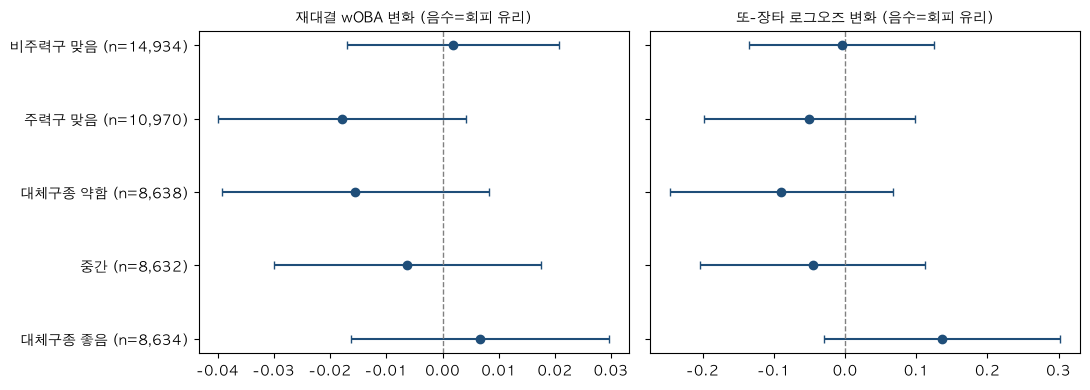

In [18]:
mod['alt_tertile'] = pd.qcut(mod['alt_quality'], 3, labels=['대체구종 약함', '중간', '대체구종 좋음'])
mod['reliance_group'] = np.where(mod['hit_is_primary'] == 1, '주력구 맞음', '비주력구 맞음')
groups = [('reliance_group', g) for g in ['비주력구 맞음', '주력구 맞음']] + [('alt_tertile', g) for g in ['대체구종 약함', '중간', '대체구종 좋음']]
sub = []
for col, g in groups:
    d = mod[mod[col] == g].copy()
    for outcome in ['woba_value', 'allowed_xbh_again']:
        r = run_model(f'sub|{col}|{g}|{outcome}', outcome, 'avoided', data=d)['table'].loc['avoided']
        sub.append({'col': col, 'group': g, 'outcome': outcome, 'n': len(d), 'avoid_rate': d['avoided'].mean(),
                    'estimate': r['estimate'], 'ci_low': r['estimate'] - 1.96 * r['std_error'],
                    'ci_high': r['estimate'] + 1.96 * r['std_error'], 'p_value': r['p_value']})
sub = pd.DataFrame(sub)
display(sub.round(4))
plt.rcParams['font.family'] = 'AppleGothic'; plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, outcome, title in zip(axes, ['woba_value', 'allowed_xbh_again'], ['재대결 wOBA 변화 (음수=회피 유리)', '또-장타 로그오즈 변화 (음수=회피 유리)']):
    s = sub[sub['outcome'] == outcome].reset_index(drop=True)
    ypos = np.arange(len(s))[::-1]
    ax.errorbar(s['estimate'], ypos, xerr=[s['estimate'] - s['ci_low'], s['ci_high'] - s['estimate']], fmt='o', color='#1f4e79', capsize=3)
    ax.axvline(0, color='gray', lw=1, ls='--')
    ax.set_yticks(ypos); ax.set_yticklabels([f"{g} (n={n:,})" for g, n in zip(s['group'], s['n'])])
    ax.set_title(title, fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / '08_avoidance_effect_by_condition.png', dpi=150)
plt.show()

## 6. 해석

* **표본.** 재대결 27,245건(노트북 7과 동일) 중 사전 투구가 200개 미만인 1,315건(주로 2021년 시즌 초반, 사전 기록이 없는 투수)을 빼고 **25,904건, 투수 667명**으로 분석했습니다. 사전 사용률 5% 이상 대체구종은 모든 이벤트에 최소 1개 있었습니다. 모든 모형이 수렴했고 `isSingular=False`입니다(5절 구간별 소모형 2개만 랜덤 절편 분산이 0 경계라 경고가 떴고, 주 모형 결론과 무관).
* **사전 지정한 4개 검정은 전부 유의하지 않습니다.** Holm 보정 p는 0.52~0.56(보정 전 0.13~0.29).

| 결과 | 상호작용 | 추정치 | 보정 전 p |
|---|---|---|---|
| wOBA | 회피 × 맞은 구종 의존도(1 SD↑) | −0.0093 | 0.188 |
| wOBA | 회피 × 대체구종 성과(1 SD↑) | +0.0070 | 0.292 |
| 또-장타(로그오즈) | 회피 × 맞은 구종 의존도 | −0.057 | 0.235 |
| 또-장타(로그오즈) | 회피 × 대체구종 성과 | +0.069 | 0.129 |

* **방향은 가설과 어긋납니다.** "좋은 대체구종이 있으면 회피가 더 유리"라면 `avoided:alt_quality_z`가 **음수**여야 하는데 네 모형 모두 +(회피 이득이 줄어드는 쪽)입니다. 구간별로 봐도 대체구종이 좋은 3분위에서 오히려 회피 효과가 가장 불리하게(또-장타 +0.136, p=0.11) 나옵니다. "주력구를 피하면 손해"라면 `avoided:hit_reliance_z`가 **양수**여야 하는데 −(주력구를 피할 때 더 유리한 쪽)입니다(주력구 맞음 구간 −0.018 wOBA, p=0.11; 비주력구 구간 +0.002). 둘 다 유의하지 않으므로 "반대 방향의 효과가 있다"고 주장할 수는 없고, "미리 세운 방향의 가설을 지지하는 증거가 없다"가 정직한 요약입니다.
* **로버스트니스 일치.** RVAE+`pitch_family` 통제(노트북 7 방식), 주력구 이진 정의, 가중평균 대체 성과, 수축 상수 k 0.5배·2배 — 10개 변형 모두 같은 부호·비유의(p 0.10~0.38)입니다.
* **왜 못 찾았나 — 두 가지를 구분해야 합니다.**
  1. *검정력.* 상호작용 SE는 wOBA 기준 약 0.007/SD라서, 약 ±0.02 wOBA/SD보다 작은 조건 차이는 이 표본으로 구분할 수 없습니다. "차이가 없다"의 증거가 아니라 "크지 않다 이하는 모른다"입니다.
  2. *조절변수의 변동폭 자체가 작음.* 구종별 사전 RVAE의 투수 간 진짜 분산이 작아서(수축 상수 k=459 — 결정구 459개가 쌓여야 관측값 가중치가 절반) 대체구종 성과의 최선값이 1 SD 움직여도 shrunk RVAE로 0.009 wOBA밖에 안 변합니다. 표본이 적은 구종의 성적을 믿지 않도록 보정한 결과이고, 그 보정이 옳다면 '좋은 대체구종'은 투수들 사이에서 눈에 띄게 다르지 않다는 뜻이기도 합니다. 그러면 이 조절변수로 회피 효과가 크게 갈릴 여지도 작습니다.
* **발표용 문장.** "회피가 유리해지는 조건을 사전에 정한 두 변수(맞은 구종 의존도, 대체구종 사전 성과)로 검정했지만, 어느 쪽도 회피 효과를 유의하게 가르지 못했다(Holm 보정 p≥0.52). 방향도 가설과 일치하지 않았다. 다만 조건 간 차이가 ±0.02 wOBA/SD보다 작다면 이 데이터로는 구별할 수 없다." — 결과가 아니라 *연구 질문을 구체화한 것*이 이 노트북의 기여입니다.
* **한계.** (1) 회피는 투수의 선택이라 상호작용도 인과가 아닌 연관입니다(예: 어려운 타자를 상대할 때 회피할 수 있는데 그 상대 난이도는 통제되지 않음). (2) 구종 사전 성과의 RVAE는 GBM 기대값 기준이고 GBM은 전체 기간으로 학습돼, 사전 성과 계산에 미래 정보가 미세하게 섞일 수 있습니다(재대결 결정구 하나의 영향은 미미). 조절변수 자체는 해당 경기 이전 투구만 씁니다. (3) 구종 사전 성과는 타석을 끝낸 투구만 사용합니다(Statcast research CSV에 투구 단위 run value가 없음). (4) `avoided`는 재대결 타석 전체에서 한 번이라도 맞은 구종을 안 던졌는지의 이진 요약입니다.
